## Assignment 4 - Distributed Kalman Filtering

- **Topic:** Distributed state estimation of a target
- **Assessment:** The assignment will be graded according to the grading rubric on Brightspace.


- **Deadline:** 27-03-2026, 17:00
- **Submitting: SUBMIT ONLY `assignment4_groupNumber.ipynb` TO BRIGHTSPACE**. 
where groupNumber is your group number.


## Instructions
**Installation:** 
The virtual environment `venvPSF` has all the necessary packages pre-installed. Make sure to select the virtual environment when running the code. This can be done in the Jupyter notebook (in vscode) by clicking select kernel in the top right, then python environments, then myenv (python 3.11.9).

If you choose to install the virtual environment yourself, the full list of dependencies is in requirements.txt. This can be done using the steps as shown in howToInstallVirtualEnvironments.txt

You may not use other packages for algorithm-related calculations.
You only need to complete (and submit) this file.
Please do not change the additional files `helper.py` and `linAlg.py` and the data file `tracking_data.npz` as this might result in breaking the assignment.


## AI Related Policy
The use of AI is not allowed.


## Information
Please fill in your group number, names and student numbers in the cell below.

In [ ]:
# YOUR ANSWER HERE

STUDENT_1_NAME = "Giuliano Moroni"
STUDENT_1_STUDENT_NUMBER = "5680204"

STUDENT_2_NAME = "Ian Michel"
STUDENT_2_STUDENT_NUMBER = "6545475"

### Description and Objectives

The primary objective of this assignment is to estimate the position of a maneuvering target in 2D using a network of anchors. The target is traveling along an unknown trajectory in two dimensions, within the sensing range of the anchors, which have fixed positions. The anchors can measure the radial distance between themselves and the target throughout its journey, with some noise.

We consider a scenario similar to (but not identical to) the figure shown below. In the figure, a network of fixed-position anchors (blue circles) measures the radial distances (red circles) between themselves and the target (represented as a purple triangle). To estimate the target's position the anchors need to communicate with one another, however, they are only allowed to interact with their immediate neighbors in the network as indicated by the gray dashed lines.

The main focus will be to collaboratively estimate the target's position using distributed state estimation, by implementing a distributed Kalman filter formulation.
\
![alt text](multiagent_tracking.png "Title") 

Each anchor is denoted by an integer $n \in \{1, 2, \dots, N\}$ where $N$ is the number of anchors in the network. 
At each time step $k$, anchors measure the squared distance $(d_{n,k})^2 \in \mathbb{R}^+$ between their (fixed) positions $\mathbf{z}_n \in \mathbb{R}^2$ and the target position $\mathbf{p}_k \in \mathbb{R}^2$ as
$$
    d_{n,k} \triangleq ||\mathbf{z}_n - \mathbf{p}_k ||_2.
$$
Unfortunately the measurement model is nonlinear and not suitable for a standard Kalman filter in this form.
We can however, tweak this formulation to obtain a linear form by squaring the distance and expanding the squared norm as
\begin{aligned}
    (d_{n,k})^2 &=  ||\mathbf{z}_n - \mathbf{p}_k ||_2^2 = (\mathbf{z}_n - \mathbf{p}_k)^T (\mathbf{z}_n - \mathbf{p}_k), \\
              &= (\mathbf{z}_n)^T \mathbf{z}_n - 2 (\mathbf{z}_n)^T \mathbf{p}_k + \mathbf{p}_k^T \mathbf{p}_k, \\
    (d_{n,k})^2 - (\mathbf{z}_n)^T \mathbf{z}_n &= - 2 (\mathbf{z}_n)^T \mathbf{p}_k + \mathbf{p}_k^T \mathbf{p}_k, \\
    y_{k,n} &= \tilde{\mathbf{C}}_n \tilde{\mathbf{p}}_k,
\end{aligned}
where $y_{k,n} \triangleq (d_{n,k})^2 - ||\mathbf{z}_n||_2^2, \quad  \tilde{\mathbf{C}}_n \triangleq \begin{bmatrix}  - 2 (\mathbf{z}_n)^T  &  1 \end{bmatrix}, \quad  \tilde{\mathbf{p}}_k \triangleq  \begin{bmatrix} \mathbf{p}_k^T & ||\mathbf{p}_k||_2^2 \end{bmatrix}^T$.
Notice that we added $||\mathbf{p}_k||_2^2$ as a state variable to make this measurement model linear.

To use this approach, let us define the state vector of the target as 
$$ 
\mathbf{x}_k \triangleq \begin{bmatrix} \mathbf{p}_k^T & \dot{\mathbf{p}}_k^T &  ||\mathbf{p}_k||_2^2 \end{bmatrix}^T,
$$
where $ \dot{\mathbf{p}}_k \in \mathbb{R}^2 $ represents the velocity vector.
We can now formulate a state space model to use it for state estimation. 
Denote the state space equations as
\begin{aligned}
    \mathbf{x}_{k+1} &= \mathbf{A} \mathbf{x}_k + \mathbf{w}, \quad \mathbf{w} \sim \mathcal{N}(0, \mathbf{Q}), \\
    y_{k,n} &= \mathbf{C}_n \mathbf{x}_k + v, \quad v \sim \mathcal{N}(0, R),
\end{aligned}
where we choose the dynamic model matrix $\mathbf{A}$ and $\mathbf{C}_n$ as
\begin{aligned}
    \mathbf{A} &\triangleq \text{blkdiag} \biggl( \begin{bmatrix} 1 & \Delta t_k \\ 0 & 1 \end{bmatrix} \otimes \mathbb{I}_2, 1 \biggr), \\
    \mathbf{C}_n &\triangleq \begin{bmatrix}  - 2 (\mathbf{z}_n)^T & 0 & 0 & 1 \end{bmatrix}, \\
\end{aligned}
and $ \Delta t_k $ is the time difference between time step $k+1$ and $k$.

### Provided data
First let us load the simulated data, the data consists of the following elements
- `dt` $\in \mathbb{R}^+$ (float): Time difference between consecutive time steps
- `T` $\in \mathbb{N}$ (int): Number of time steps where time steps $k$ span from $0$ to $T$
- `edge_list` (list of tuples): Stores the edges as `(i,j)` which denotes the connection between anchors `i` and `j`.
- `anchor_positions` $\in \mathbb{R}^{2 \times N}$ (numpy array): Horizontally stacked anchor position vectors $[\mathbf{z}_1, \ \mathbf{z}_2, \ \dots, \mathbf{z}_N]$ 
- `measurement_list` $\in \mathbb{R}^{N \times T}$ (numpy array): List of measurements $y_{k,n}$ where `measurement_list[n, k]` denotes the measurement of anchor `n` at time step `k`.
- `true_positions` $\in \mathbb{R}^{2 \times T}$ (numpy array): Horizontally stacked true positions of the target $[\mathbf{p}_0, \ \mathbf{p}_2, \ \dots, \mathbf{p}_{T-1}]$  

After we load the data, let us see what the anchor network, the ground truth trajectory and measurements look like. Note that the measurements plotted as two dimensional points just for clarity. Actual measurements look more like circles since we only measure the radial distances.

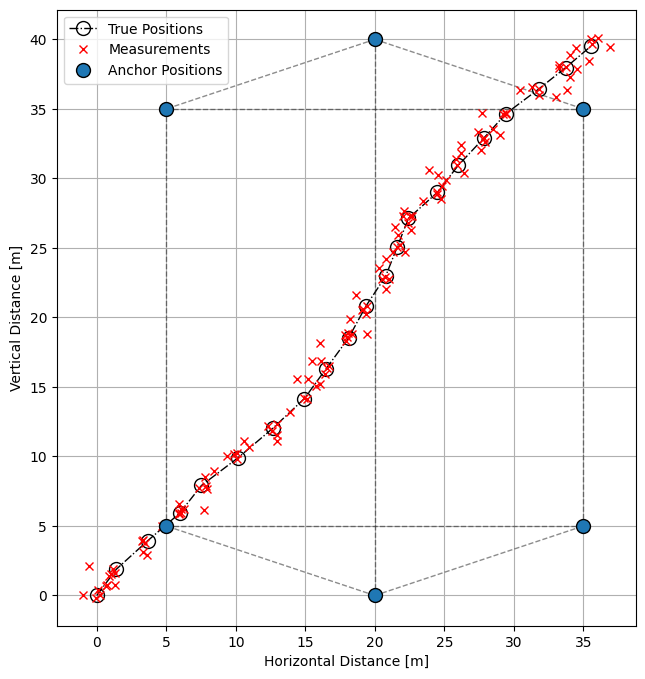

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from linAlg import block_diag
import helper as helper


plt.rcParams.update(
    {
        "lines.linewidth": 1.0,
        "lines.markersize": 10,
        "lines.markeredgewidth": 1.0
        
    }
)
measurement_list, true_states, anchor_positions, edge_list, dt, T, model_parameters = helper.initializeDKFAssignment()

helper.plotMeasurementsAndGroundTruth(true_states, anchor_positions, edge_list, model_parameters)

### Task 1: Construct Matrices
Construct dynamic model matrix $\mathbf{A}$ and measurement model matrices $\mathbf{C}_n$ as described above. 
You can use the parameters `initial_mean` vector,`initial_covariance` matrix, process covariance matrix `Q` and measurement noise variance `R` provided below for the rest of the assignment. 
You can use `block_diag` function to construct $\mathbf{A}$.


### Analysis:
Elaborate on the following:
- Why do we add the new variable $||\mathbf{p}_k||_2^2$ to the state vector? If we wanted to avoid doing this, how would you proceed? 

In order to represent out system model in a linear measurement i.e. as $ y = Cx + v$, we expand the sqaured distance to isolate the non-linear term of the considered system ($\mathbf{p}_k^T \mathbf{p}_k$), and absorb it such that the filter treates it as a single, linear variable. To avoid using this trick we would keep the standard, physically accurate state vector $x_k = [\mathbf{p}_k^T, \dot{\mathbf{p}}_k^T]^T$, and deal with the non-linearity directly. As the measurement model is now in the form $y = h(x) + v$ ($y_{n,k} = ||\mathbf{z}_n - \mathbf{p}_k ||_2$), to accurate estimate states we would use a UKF or EKF scheme.

- Comment on the dynamic update model of the state variable $||\mathbf{p}_k||_2^2$. Does it properly represent the true dynamics? If not, what can be done to mitigate its drawbacks?

We are able to deterministically define our 3rd state-vector $||\mathbf{p}_{k+1}||_2^2$ via:
$$
||\mathbf{p}_{k+1}||_2^2 = (\mathbf{p}_k + \dot{\mathbf{p}}_k \Delta t)^T (\mathbf{p}_k + \dot{\mathbf{p}}_k \Delta t).
$$
However, the relationship implied by the selected state-transition matrix $\mathbf{A}$, 
$$
||\mathbf{p}_{k+1}||_2^2 = ||\mathbf{p}_k||_2^2 + \text{Noise},
$$
represents a much simpler, linear version of our dynamics, and as such does not preserve the true dynamics of the system. We trade off kinematic accuracy, as we rely heavily on our exact, high-rate measurements to correct this state-variable that only exist to have a linear measurement model formulation. As such, by using a properly tuned process noise matrix $\mathbf{Q}$ we are able to give the filter enough flexibility to overwrite the inaccurate dynamics.

In [3]:

from numpy import eye


As = np.array([[1, dt], [0, 1]])
I2 = np.eye(2)
A = block_diag(np.kron(As, I2), np.eye(1))
C = []
for n in range(anchor_positions.shape[1]):
    zn = anchor_positions[:, n]
    # Construct Cn as a 1x5 matrix
    Cn = np.array([[-2*zn[0], -2*zn[1], 0, 0, 1]])
    C.append(Cn)
C= np.vstack(C)

##### END HERE #####

# Initial Mean and covariance
initial_estimate = np.zeros((5,1))
initial_covariance = np.eye(initial_estimate.shape[0])*100.0

# Process noise covariance (Q) and Measurement noise covariance (R)
Q = np.diag([1.5, 0.15, 1.5, 0.15, 100.0])
R = 0.75


### Task 2: Centralized Kalman Filter Implementation
Implement a centralized version of the Kalman filter by using all measurements generated by the anchors to update the state estimate. After each time step, append your mean and covariance estimates to lists `centralized_means` and `centralized_covariances` respectively.

Note that for the centralized measurement update version you can use an augmented measurement model in the form
\begin{aligned}
    \begin{bmatrix} y_{1,k} \\  y_{2,k} \\ ... \\  y_{N,k} \end{bmatrix} &= \begin{bmatrix} \mathbf{C}_1 \\  \mathbf{C}_2 \\ ... \\  \mathbf{C}_N   \end{bmatrix}  \mathbf{x}_k + \mathbf{v}, \quad \mathbf{v} \sim \mathcal{N}(0, R \ \mathbb{I}_N).
\end{aligned}

### Analysis:
Elaborate on the following:
- Comment on the centralized Kalman filter mean estimates. Explain how $||\mathbf{p}_k||_2^2$ is estimated without even measuring the variable itself.

The centralized mean estimates from the centralized (discrete vector) Kalman Filter, are highly accurate and follow the true path with low variances. By stacking all $N$ measurements into a single global observation vector, centralized KF leverages all measurements at each time step. This simutaneous processing optimally smooths out the uncorreltated, zero-mean measurement noise across all anchors, providing the highly stable and accurate trajectories seen in the below plot. 

While there is no direct physical sensor that outputs the value of $||\mathbf{p}_k||_2^2$, the variable is observable through the geometry of the augmented, centralized measurement model. Considering our stacked $C$ matrix, we are solving a system of linear equations with spatially distributed anchor positions, where the coefficient for $||\mathbf{p}_k||_2^2$ is always a constant 1, ensuring linear independence across the columns:
$$
\mathbf{C}_{stack} = \begin{bmatrix} 
- 2 (\mathbf{z}_1)^T & 0 & 0 & 1 \\
- 2 (\mathbf{z}_2)^T & 0 & 0 & 1 \\
\vdots & \vdots & \vdots & \vdots \\
- 2 (\mathbf{z}_N)^T & 0 & 0 & 1 
\end{bmatrix}.
$$

Therefore, as long as there exist 3 non-spatially correlated anchors (not colinear), this staked system is fully determined, and the KF's measurement update actas as a recurisve least-sqaures estimateor, simuataneously triangulating both the position $\mathbf{p}_k$, and $||\mathbf{p}_k||_2^2$. 

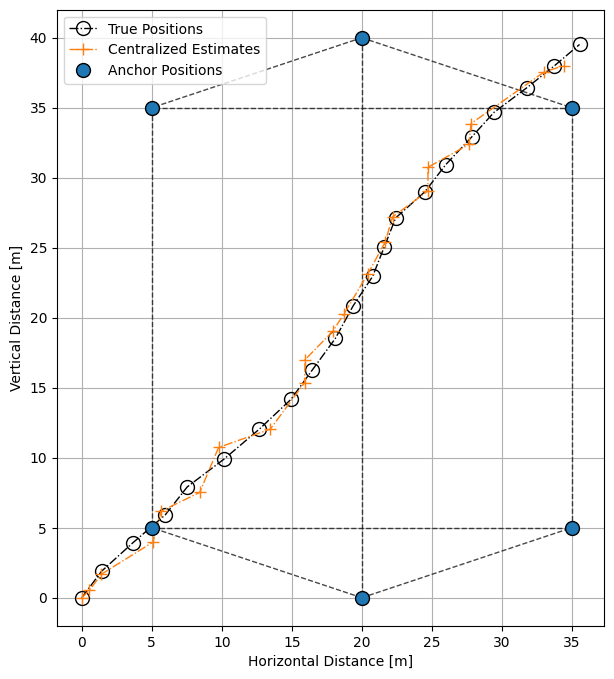

In [4]:
# Centralized estimates
centralized_means = [initial_estimate]
centralized_covariances = [initial_covariance]

#####  YOUR CODE HERE #####
x_last = initial_estimate
P_last = initial_covariance

for k in range(T):
    x_pred = A @ x_last
    P_pred = A @ P_last @ A.T + Q

    Sk = R*np.eye(6) + C @ P_pred @ C.T
    Kk = P_pred @ C.T @ np.linalg.inv(Sk)
    y_k = measurement_list[:, k:k+1]

    x_est = x_pred + Kk @ (y_k - C @ x_pred)
    P_est = P_pred - Kk @ C @ P_pred
    centralized_means.append(x_est)
    centralized_covariances.append(P_est)
    x_last = x_est
    P_last = P_est

##### END HERE #####

helper.plotCentralizedKFEstimate(true_states, anchor_positions, edge_list, centralized_means)

### Task 3: Distributed Kalman Filter Implementation
Implement a distributed Kalman filter using the formulation given below. After each time step, append your mean and covariance estimates for anchor `n` to lists `local_means[n]` and `local_covariances[n]` respectively.




Assume that anchor $n$ has access to measurements of itself and its neighbors $j \in \mathcal{N}_n \cup \{n\}$.
At time $k$, a local estimate can be computed using the following procedure:

\begin{aligned}
&\text{Time Update:} \\
&\hat{x}_{n, k+1 | k} = A \hat{x}_{n, k+1 | k}  \\
&P_{n, k+1 | k} = A P_{n, k+1 | k} A^T + Q  \\
\newline
&\text{Measurement Update:} \\
&x_{n,k} = \hat{x}_{n, k | k-1} \\
&P_{n,k} = P_{n, k | k-1} \\
&\text{For each} \ j \in \mathcal{N}_n \cup \{n\} \ \text{repeat:} \\
& \quad S_{j,k} = C_{j} P_{n,k} C_{j}^T + R_{j} \\
& \quad K_{j,k} = P_{n,k} C_{j}^T S_{j,k}^{-1} \\
& \quad x_{n,k} = x_{n,k} + K_{j,k} (y_{j,k} - C_{j} x_{n,k})\\
& \quad P_{n,k} = P_{n,k} - K_{j,k}  C_{j}  P_{n,k} \\
&\text{end} \\
&\hat{x}_{n, k | k} = x_{n,k} \\
&P_{n, k | k} = P_{n,k} \\
\end{aligned}

Alternatively a more compact from  can be expressed, similar to the information form KF, as
\begin{aligned}
&\text{Time Update:} \\
&\hat{x}_{n, k+1 | k} = A \hat{x}_{n, k | k}  \\
&P_{n, k+1 | k} = A P_{n, k | k} A^T + Q  \\
\newline
&\text{Measurement Update:} \\
&P_{n,k | k}^{-1} = P_{n,k | k-1}^{-1} + \sum_{j \in \mathcal{N}_n \cup \{n\}} C_{j}^T  R_{j}^{-1}  C_{j}  \\
&\hat{x}_{n, k | k} = \hat{x}_{n,k | k-1} + P_{n,k|k} \sum_{j \in \mathcal{N}_n \cup \{n\}} C_{j}^T R_{j}^{-1} (y_{j, k} - C_{j}\hat{x}_{n,k | k-1}  )\\
\end{aligned}

### Analysis:
Elaborate on the following:
- Analyze the behavior of the decentralized Kalman filter. At a glance, how does it differ from the centralized one?
- How would the estimates change if you change the number of edges. Comment on what would happen if all edges were removed.
- How many neighbors does an anchor need for a feasible solution? In other words, how many neighbors are required for each anchor to estimate a position? You may provide a geometric interpretation.



1) The most obvious difference between the behaviour of the Kalman filter and the decentralized Kalman filter is the fact that each anchor relies on itself (and neighbors) to make a prediction. Hence, it is a local Kalman filter with less data to use (with some "help" from neighbors). This means that the individual estimate of each anchor is worse than the one of the centralized Kalman filter (which has all the data available to it). We can see this at a glance when looking at the estimates which are farther from the center of the hexagon: the data points which are less in range of all of the anchors (especially those outside of the hexagon) tend to vary, and tend to be much farther off to the real position than the centralized Kalman filter.

2) An increase in the number of edges would increase the quality of the estimate; inversley, the less edges connected, the worse the estimate. In the extreme case, if all verteces are connected, then that will be the best decentralized Kalman filter possible (it will be mathematically equal to the centralized Kalman filter (?)). If none of the verteces are connected, then it will become the same as the "local Kalman filter" discussed in the lecture: It will still produce an estimate, but not a very good one. Particularly, if a measurement happens outside the range of an anchor, it becomes impossible for that anchor to produce a good estimate.

3) For an anchor to produce a feasable estimate, it muct have access to a measurement; if the measurement happens outside the range of that anchor, it will not be able to produce an estimate (as was mentionned in the previous point). Hence, every anchor must have X neighbors such that each measurement is inside the range of at least one of the neighbors. In this case, each anchor probably needs at least one other neighbor, preferably the one farthest away from it (on the opposite side of the hexagon). If the anchor is not on the path of the trajectory (such as the ones in the top, bottom, top left, and bottom right), it might need to additional neighbors, in order to fully be able to capture the measurement.

ALTERNATIVE INTERPRETATION:

An anchor needs at least 3 separate neighbors. If anchor A has three separate neighbors, each of these neighbors has in turn 3 separate neighbors, that means that the whole graph is connected with a degree of two from eachother (the fartest two anchors are 2 edges away from each other anchor). This means that ...

[{0}, {1}, {2}, {3}, {4}, {5}]


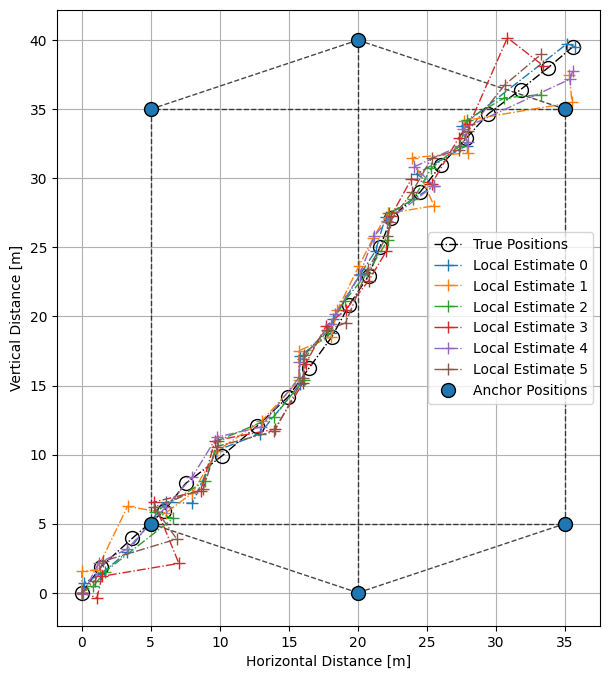

In [5]:
# Initialize per anchor variables
local_means = [[initial_estimate] for _ in range(anchor_positions.shape[1])]
local_covariances = [[initial_covariance] for _ in range(anchor_positions.shape[1])]

#### YOUR CODE HERE ####

n_anchors = anchor_positions.shape[1]
neighbors = [set([i]) for i in range(n_anchors)]
print(neighbors)

for edge in edge_list:
    i, j = int(edge[0]), int(edge[1])
    neighbors[i].add(j)
    neighbors[j].add(i)

for k in range(T):
    for i in range(n_anchors):

        x_last = local_means[i][-1]
        P_last = local_covariances[i][-1]

        x_pred = A @ x_last 
        P_pred = A @ P_last @ A.T + Q

        x_corr = x_pred.copy()
        P_corr = P_pred.copy()
        
        for j in sorted(neighbors[i]):
            Cj = C[j : j + 1, :]
            yj = measurement_list[j, k]

            Sj = Cj @ P_corr @ Cj.T + R
            Kj = P_corr @ Cj.T @ np.linalg.inv(Sj)

            innovation = yj - (Cj @ x_corr)[0, 0]
            x_corr = x_corr + Kj * innovation
            P_corr = P_corr - Kj @ Cj @ P_corr

        local_means[i].append(x_corr)
        local_covariances[i].append(P_corr)

#### END HERE ####

helper.plotDecentralizedKFEstimate(true_states, anchor_positions, edge_list, local_means)

### Task 4: Comparison
Compute the squared errors of the centralized and local position mean estimates and plot them against time instances. Make sure that the axes are labeled with appropriate units. Also include a legend with descriptive names for each estimate.

### Analysis:
- Compare and discuss the filter performances. 
- What are the main advantages and disadvantages of centralized and decentralized Kalman filters?

1) We can see from the graph below that the centraized Kalman filter generally has better performance. It performs better than most of the anchors. This is not the case towards the middle of the trajectory (where, presumably, all of the anchors have access to the measurements, and therefore have a higher quality estimate); here, both filters have similar performance (especially at t = 8 seconds, where all anchors' decentralized Kalman filter produce almost the same estimate as the centralized Kalman filter). However, at the start and end of the trajectories, when certain anchors dont have access to measurements and therefore must rely on their neighbors, who will have less data to make estimates, the centralized Kalman filter greatly outperforms most of the anchors. Despite this, some anchors, such as anchor 2, produce better estimates than the centralized Kalman filter, for most of the trajectory. This is likely due to it having "good" neighbors, which can have enough data to match (and even outperform) the Centralized Kalman filter (which might have more noisy data than less, well-placed data, and therefore lesser quality estimate).

2) The main advantage to the centralized Kalman filter is that it uses all the data possible, and hence will generally have the best estimate. However, this is more computationally expensive, and needs all anchors to be able to transmit data to eachother, which might be impossible in practive (for example, the two farthest drones in a swarm might not be able to connect through wifi (or similar), and therefore would not be able to share data to use it in a centralized Kalman filter). The decentralized Kalman filter has the opposite pro's and con's: since there is less data, each anchor will produce a worse estimate w.r.t. the centralized Kalman filter; however, in practice, it is able to combine measurements from neighboring anchors, which will lead to better estimates than each anchor running its own local Kalman filter. Furthermore, the lesser amount of data means that the decentralized Kalman filter has a lesser computational load, and therefore is easier to run on smaller anchors, such as drones.

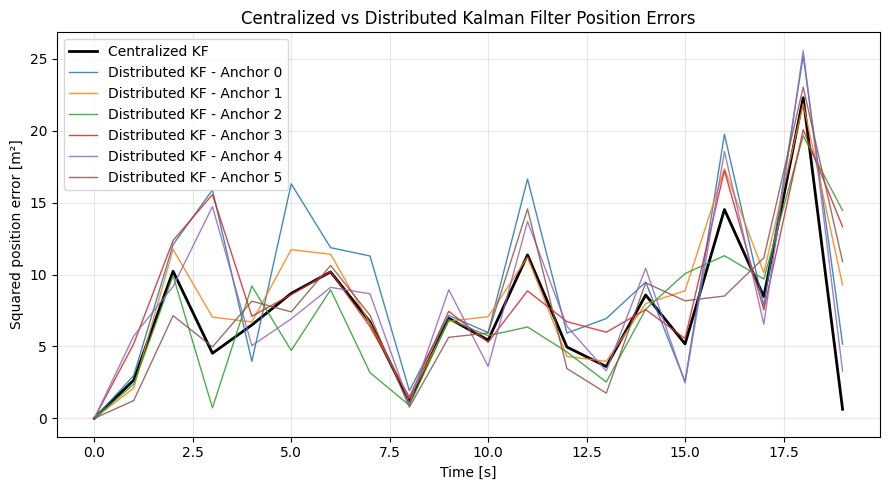

In [6]:
#### YOUR CODE HERE ####

time = np.arange(T) * dt
true_pos = true_states[:2, :T]

# Discrete Vector Kalman (Centralized) squared position error
centralized_pos = np.hstack([m[:2] for m in centralized_means[:T]])
centralized_sq_err = np.sum((centralized_pos - true_pos) ** 2, axis=0)

# Local Kalman Filter II (Local) squared position errors 
local_sq_errs = []
for i in range(n_anchors):
    local_pos_i = np.hstack([m[:2] for m in local_means[i][:T]])
    local_sq_err_i = np.sum((local_pos_i - true_pos) ** 2, axis=0)
    local_sq_errs.append(local_sq_err_i)

plt.figure(figsize=(9, 5))
plt.plot(time, centralized_sq_err, label="Centralized KF", linewidth=2.0, color="black")

for i, err in enumerate(local_sq_errs):
    plt.plot(time, err, label=f"Distributed KF - Anchor {i}", alpha=0.85)

plt.xlabel("Time [s]")
plt.ylabel("Squared position error [m²]")
plt.title("Centralized vs Distributed Kalman Filter Position Errors")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

#### END HERE ####

#### Feedback:
Please use this markdown to share any comments, suggestions, or errors you encountered in the assignment. Your feedback will help us to improve it for future years.